In [115]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns

# prison path from folder prison data
prison_path = Path('../data/prison data/crim_pris_age_linear_2_0.csv')
#import dataset
prison_data = pd.read_csv(prison_path)
prison_data.tail(5)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,age,Age class,sex,Sex,unit,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
10525,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,P_HTHAB,...,XK,Kosovo*,2016,NaN,93.02,NaN,NaN,NaN,NaN,NaN
10526,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,P_HTHAB,...,XK,Kosovo*,2017,NaN,95.82,NaN,NaN,NaN,NaN,NaN
10527,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,P_HTHAB,...,XK,Kosovo*,2018,NaN,87.13,NaN,NaN,NaN,NaN,NaN
10528,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,P_HTHAB,...,XK,Kosovo*,2019,NaN,100.58,NaN,NaN,NaN,NaN,NaN
10529,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,P_HTHAB,...,XK,Kosovo*,2020,NaN,78.33,NaN,NaN,NaN,NaN,NaN


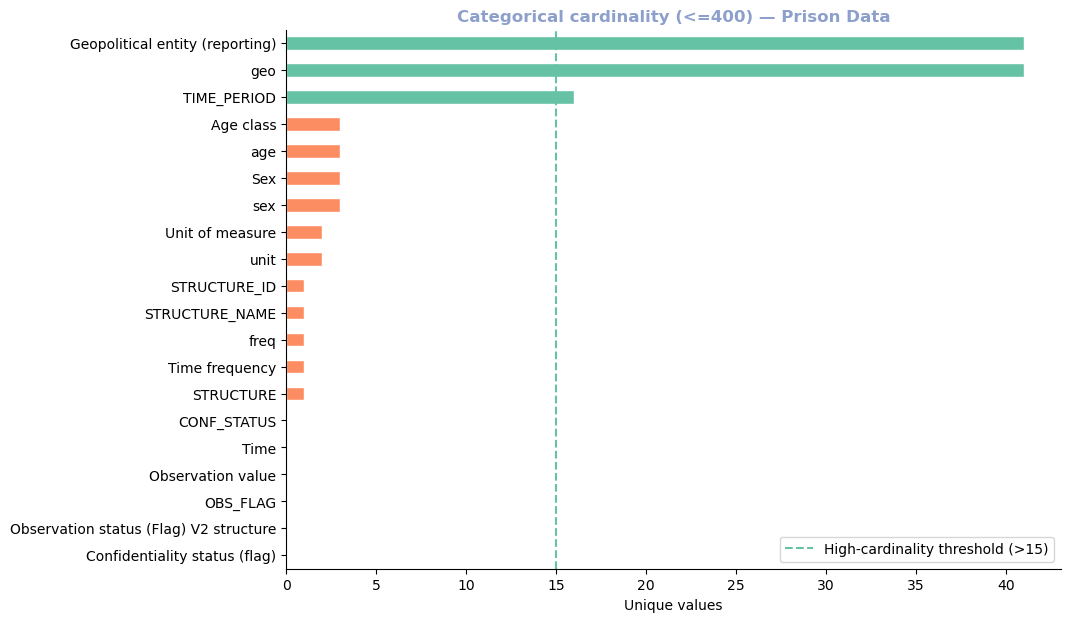

HIGH-CARDINALITY features (excluded from chart):
    'OBS_VALUE': 6564 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data):
  'Confidentiality status (flag)' (0 values): []

  'Observation status (Flag) V2 structure' (0 values): []

  'OBS_FLAG' (0 values): []

  'Observation value' (0 values): []

  'Time' (0 values): []

  'CONF_STATUS' (0 values): []

  'STRUCTURE' (1 values): ['dataflow']

  'Time frequency' (1 values): ['Annual']

  'freq' (1 values): ['A']

  'STRUCTURE_NAME' (1 values): ['Prisoners by age and sex']

  'STRUCTURE_ID' (1 values): ['ESTAT:CRIM_PRIS_AGE(1.0)']

  'unit' (2 values): ['NR', 'P_HTHAB']

  'Unit of measure' (2 values): ['Number', 'Per hundred thousand inhabitants']

  'sex' (3 values): ['F', 'M', 'T']

  'Sex' (3 values): ['Females', 'Males', 'Total']

  'age' (3 values): ['ADULT', 'JUVENILE', 'TOTAL']

  'Age class' (3 values): ['Adult', 'Juvenile', 'Total']

  'TIME_PERIOD' (16 values): ['2008', '2009', '2010', '201

In [116]:
# cardinality of the dataset
PALETTE = sns.color_palette("Set2")
CORAL, STEEL, NAVY = PALETTE[0], PALETTE[1], PALETTE[2]
def inspect_categorical(df, dataset_name):
    """Separate low- and high-cardinality categoricals, plot the former, list the latter."""
    cat_cols = df.select_dtypes(include=["object", "category", "bool", "int64", "float64"]).columns
    if len(cat_cols) == 0:
        print(f"  No categorical columns in {dataset_name}.")
        return

    card = df[cat_cols].nunique().sort_values(ascending=True)
    card_low, card_high = card[card <= 400], card[card > 400]

    if not card_low.empty:
        plt.figure(figsize=(10, max(4, len(card_low) * 0.35)))
        colors = [CORAL if v > 15 else STEEL for v in card_low]
        card_low.plot(kind="barh", color=colors, edgecolor="white")
        plt.axvline(15, color=CORAL, ls="--", lw=1.5,
                    label="High-cardinality threshold (>15)")
        plt.title(f"Categorical cardinality (<=400) — {dataset_name}",
                  fontweight="bold", color=NAVY)
        plt.xlabel("Unique values"); plt.legend(); sns.despine()
        plt.show()

    if not card_high.empty:
        print("HIGH-CARDINALITY features (excluded from chart):")
        for col, val in card_high.items():
            print(f"    '{col}': {val} unique values — needs grouping/target encoding")
        print()

    print(f"  Reviewing unique values ({dataset_name}):")
    for col in card_low.index:
        uv = sorted(df[col].dropna().astype(str).unique())
        print(f"  '{col}' ({len(uv)} values): {uv}\n")

inspect_categorical(prison_data, "Prison Data")

In [117]:
# Drop columns 
prison_data.drop(columns=['STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Time frequency', 'unit', 'age', 'sex', 'Confidentiality status (flag)',
                          'OBS_FLAG', 'Observation value', 'Time', 'CONF_STATUS', 'STRUCTURE', 'Observation status (Flag) V2 structure'], inplace=True)
prison_data.sample(3)

,Age class,Sex,Unit of measure,geo,Geopolitical entity (reporting),TIME_PERIOD,OBS_VALUE
4855,Juvenile,Males,Number,FI,Finland,2009,99.00
765,Adult,Females,Per hundred thousand inhabitants,EL,Greece,2023,11.05
4924,Juvenile,Males,Number,IE,Ireland,2016,13.00


In [118]:
# We separate the row where the 'Age class' and 'Sex' columns have the value 'Total'
total_values = prison_data[(prison_data['Age class'] == 'Total') | (prison_data['Sex'] == 'Total')]
# then drop them from the original dataset
prison_data.drop(total_values.index, inplace=True)
total_values.sample(10)

,Age class,Sex,Unit of measure,geo,Geopolitical entity (reporting),TIME_PERIOD,OBS_VALUE
10259,Total,Total,Per hundred thousand inhabitants,LT,Lithuania,2016,235.93
10187,Total,Total,Per hundred thousand inhabitants,IE,Ireland,2008,78.16
3240,Adult,Total,Per hundred thousand inhabitants,IT,Italy,2020,106.29
9994,Total,Total,Per hundred thousand inhabitants,BG,Bulgaria,2023,85.70
9393,Total,Total,Number,BG,Bulgaria,2023,5526.00
8242,Total,Males,Number,CH,Switzerland,2018,6215.00
7918,Total,Females,Per hundred thousand inhabitants,LV,Latvia,2013,31.62
2402,Adult,Total,Number,BE,Belgium,2011,10936.00
7774,Total,Females,Per hundred thousand inhabitants,FR,France,2011,6.47
8018,Total,Females,Per hundred thousand inhabitants,PT,Portugal,2012,13.75


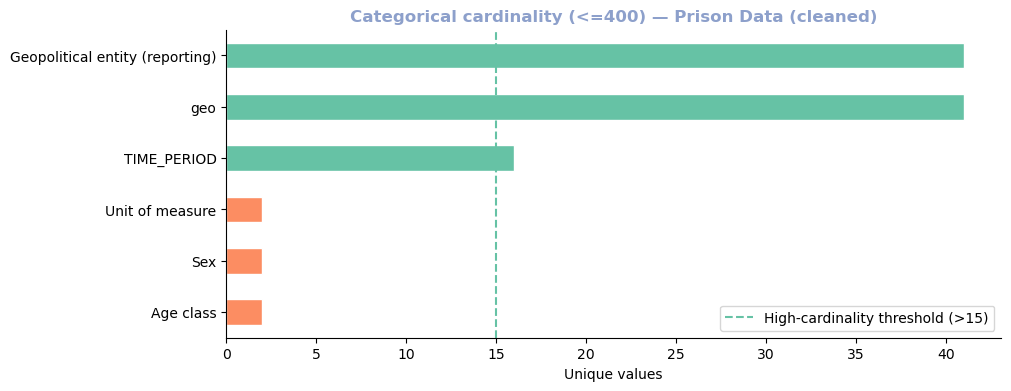

HIGH-CARDINALITY features (excluded from chart):
    'OBS_VALUE': 2800 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data (cleaned)):
  'Age class' (2 values): ['Adult', 'Juvenile']

  'Sex' (2 values): ['Females', 'Males']

  'Unit of measure' (2 values): ['Number', 'Per hundred thousand inhabitants']

  'TIME_PERIOD' (16 values): ['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

  'geo' (41 values): ['AL', 'AT', 'BA', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IS', 'IT', 'LI', 'LT', 'LU', 'LV', 'ME', 'MK', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO', 'RS', 'SE', 'SI', 'SK', 'TR', 'UKC-L', 'UKM', 'UKN', 'XK']

  'Geopolitical entity (reporting)' (41 values): ['Albania', 'Austria', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'England and Wales', 'Estonia', 'Finland', 'France', 'Germany'

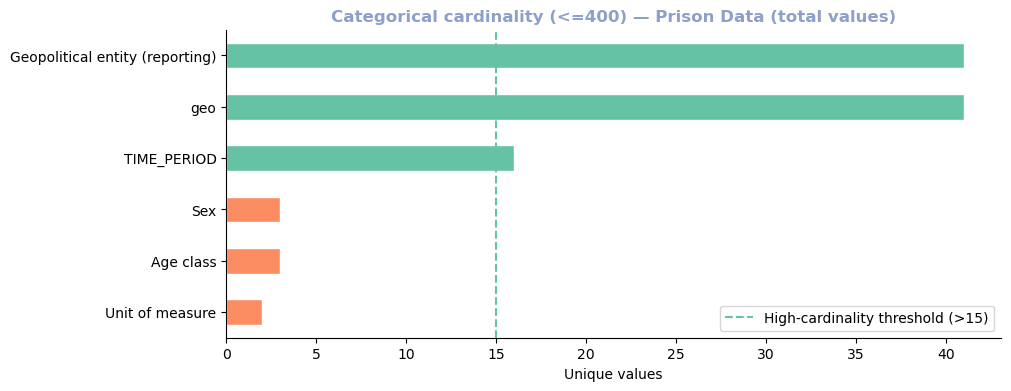

HIGH-CARDINALITY features (excluded from chart):
    'OBS_VALUE': 4698 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data (total values)):
  'Unit of measure' (2 values): ['Number', 'Per hundred thousand inhabitants']

  'Age class' (3 values): ['Adult', 'Juvenile', 'Total']

  'Sex' (3 values): ['Females', 'Males', 'Total']

  'TIME_PERIOD' (16 values): ['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

  'geo' (41 values): ['AL', 'AT', 'BA', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IS', 'IT', 'LI', 'LT', 'LU', 'LV', 'ME', 'MK', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO', 'RS', 'SE', 'SI', 'SK', 'TR', 'UKC-L', 'UKM', 'UKN', 'XK']

  'Geopolitical entity (reporting)' (41 values): ['Albania', 'Austria', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'England and Wales', 'Estonia', 'Finlan

In [119]:
inspect_categorical(prison_data, "Prison Data (cleaned)")
inspect_categorical(total_values, "Prison Data (total values)")

In [120]:
# Save the cleaned dataset in Data to export folder
prison_data.to_csv('../data/Data to export//cleaned_prison_data.csv', index=False)
total_values.to_csv('../data/Data to export//total_values_prison_data.csv', index=False)